# Customer Segmentation
Segment mall customers using K-Means clustering based on income and spending behavior.

## 1. Load and Explore the Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

df = pd.read_csv('Mall_Customers.csv')
print('Shape:', df.shape)
df.head()

Shape: (200, 5)


,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [2]:
df.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


In [3]:
print('Missing values:')
print(df.isnull().sum())

Missing values:
CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64


## 2. Exploratory Data Analysis

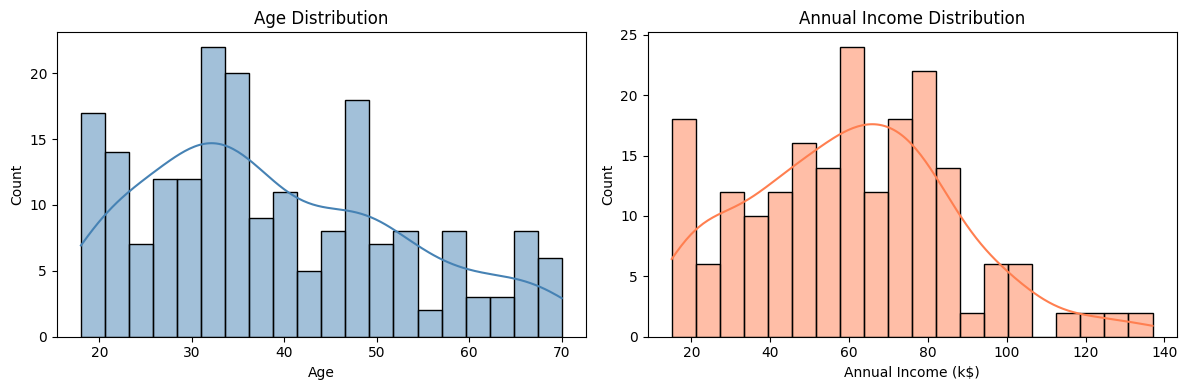

In [4]:
# Age and Income distributions
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.histplot(df['Age'], bins=20, kde=True, ax=axes[0], color='steelblue')
axes[0].set_title('Age Distribution')

sns.histplot(df['Annual Income (k$)'], bins=20, kde=True, ax=axes[1], color='coral')
axes[1].set_title('Annual Income Distribution')

plt.tight_layout()
plt.show()

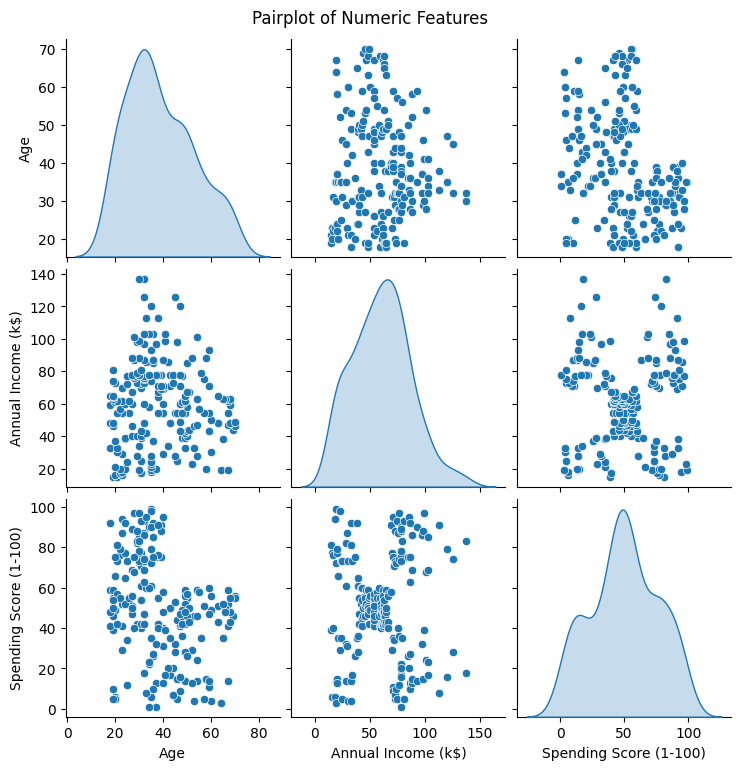

In [5]:
# Pairplot of numeric features
sns.pairplot(df[['Age', 'Annual Income (k$)', 'Spending Score (1-100)']], diag_kind='kde')
plt.suptitle('Pairplot of Numeric Features', y=1.02)
plt.show()

## 3. Preprocessing
Use only Annual Income and Spending Score as clustering features.

In [6]:
X = df[['Annual Income (k$)', 'Spending Score (1-100)']].values
print('Feature matrix shape:', X.shape)

Feature matrix shape: (200, 2)


## 4. Elbow Method
Find the optimal number of clusters by plotting inertia vs. k.

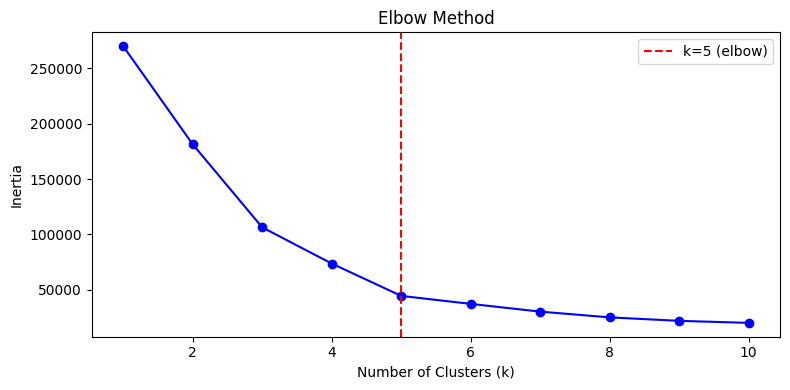

In [7]:
inertias = []
k_range = range(1, 11)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X)
    inertias.append(km.inertia_)

plt.figure(figsize=(8, 4))
plt.plot(k_range, inertias, 'bo-')
plt.axvline(x=5, color='red', linestyle='--', label='k=5 (elbow)')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method')
plt.legend()
plt.tight_layout()
plt.show()

## 5. K-Means Clustering (k=5)

In [8]:
kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)
df['Cluster'] = kmeans.fit_predict(X)
centroids = kmeans.cluster_centers_

print('Cluster sizes:')
print(df['Cluster'].value_counts().sort_index())

Cluster sizes:
Cluster
0    81
1    39
2    22
3    35
4    23
Name: count, dtype: int64


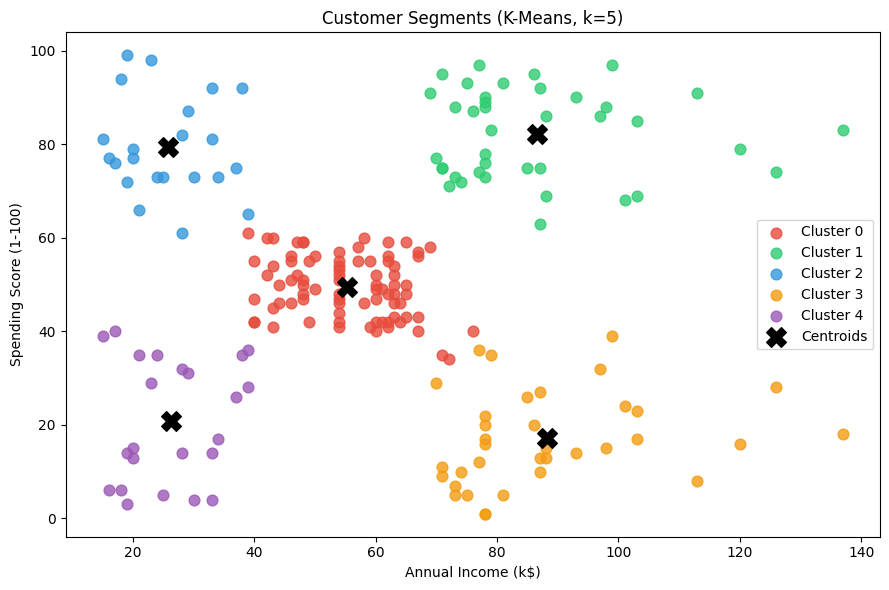

In [9]:
# Cluster scatter plot
colors = ['#e74c3c', '#2ecc71', '#3498db', '#f39c12', '#9b59b6']
plt.figure(figsize=(9, 6))

for i in range(5):
    subset = df[df['Cluster'] == i]
    plt.scatter(subset['Annual Income (k$)'], subset['Spending Score (1-100)'],
                color=colors[i], label=f'Cluster {i}', s=60, alpha=0.8)

plt.scatter(centroids[:, 0], centroids[:, 1],
            color='black', marker='X', s=200, zorder=5, label='Centroids')

plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.title('Customer Segments (K-Means, k=5)')
plt.legend()
plt.tight_layout()
plt.show()

## 6. Cluster Interpretation

| Cluster | Income | Spending | Profile |
|---------|--------|----------|---------|
| 0 | High | Low | Careful high-earners — earn a lot but spend conservatively |
| 1 | Low | Low | Budget-conscious — low income and low spending |
| 2 | Average | Average | Moderate customers — balanced income and spending |
| 3 | Low | High | Impulsive spenders — low income but high spending |
| 4 | High | High | Target customers — high income and high spending |

> **Cluster 4** (high income, high spending) is the most valuable segment for targeted marketing.

In [10]:
# Cluster summary statistics
summary = df.groupby('Cluster')[['Annual Income (k$)', 'Spending Score (1-100)', 'Age']].mean().round(1)
print('Cluster Means:')
print(summary)

Cluster Means:
         Annual Income (k$)  Spending Score (1-100)   Age
Cluster                                                  
0                      55.3                    49.5  42.7
1                      86.5                    82.1  32.7
2                      25.7                    79.4  25.3
3                      88.2                    17.1  41.1
4                      26.3                    20.9  45.2
